#Predictive Modeling for Click-Through Rate Optimization


### **1. Business Context**

ConnectSphere Digital runs online advertising campaigns for multiple clients. A major challenge in digital marketing is wasted ad spend: many ads are shown to users who are unlikely to click. This reduces Click-Through Rate (CTR) and Return on Ad Spend (ROAS).
   
The company wants a data-driven system to identify users with high click probability, so ads can be targeted more efficiently.

### **2. Problem Statement**

The objective is to develop a predictive model that estimates whether a user will click on an advertisement (binary classification: 1 = clicked, 0 = not clicked). The model should leverage demographic and behavioral data to help optimize ad targeting strategies.

###**3. Dataset Description**

  The dataset (advertising.csv) includes the following features:
    
      * Daily Time Spent on Site (numeric) → Time user spends daily on site.

      * Age (numeric) → User’s age.

      * Area Income (numeric) → Average income of the user’s area.

      * Daily Internet Usage (numeric) → Average internet usage per day.

      * Ad Topic Line (categorical/text) → The subject line of the advertisement.

      * City (categorical) → User’s city.

      * Male (binary) → Gender indicator.

      * Timestamp (datetime) → Date/time of ad impression.

      * Clicked on Ad (binary target variable) → 1 if clicked, 0 otherwise.

###**4. Preprocessing Steps**

 To prepare data for logistic regression, we applied the following:

      * Handling Missing Data

      * Checked for null values; imputed or dropped if necessary.

      * Outlier Detection/Handling

      * Examined Age, Daily Time Spent on Site, and Daily Internet Usage distributions.

      * Clipped extreme outliers (values beyond realistic ranges).

      * Feature Engineering

      * Extracted Hour of Day and Day of Week from Timestamp.

      * Optional: Derived ratio features like Time Spent / Area Income.

      * Categorical Encoding

      * Encoded Male as binary (0/1).

      * Dropped high-cardinality features (Ad Topic Line, City) unless domain relevance was established.

      * Feature Scaling

      * Standardized numerical features (Age, Daily Time Spent, Daily Internet Usage, Area Income) using StandardScaler for logistic regression stability.

      * Data Split

      * Train/Test split (80/20).

      * Scaling fit only on train set and applied to test set.

###**5. Model Development**

    * Algorithm: Logistic Regression (chosen for interpretability and efficiency).

    * Pipeline:

      - Preprocessing (scaling, encoding, feature selection).

      - Logistic regression model.

    * Output: Binary prediction (likely to click vs unlikely to click).

###**6. Model Evaluation**

We used multiple metrics to assess performance:

      * Accuracy → Overall correctness of predictions.

      * Precision → Correctly predicted clicks among all predicted clicks (important to reduce wasted spend).

      * Recall → Ability to capture actual clickers (important for maximizing reach).

      * F1 Score → Balance of precision and recall.

      * ROC Curve & AUC → Tradeoff between true positive rate and false positive rate.

      * Confusion Matrix → Detailed classification breakdown.

###**7. Results (Example – depends on your run)**

    Accuracy: ~92%

    Precision: ~90%

    Recall: ~93%

    AUC: ~0.95

This shows the model performs well in distinguishing likely vs. unlikely clickers.

###**8. Business Impact**

    Improved CTR → Ads shown to users with higher likelihood of engagement.

    Reduced Ad Waste → Lower spend on users with minimal probability of clicking.

    Better ROAS → Clients see stronger returns.

    Competitive Advantage → Data-driven targeting strategy enhances ConnectSphere’s market position.

###**9. Deliverables**

    ctr_model.pkl → Serialized pipeline (preprocessing + logistic regression).

    custom_transformers.py → Script for data transformation and handling ouliers and top categorical data.

    train_model.py → Script for training and saving model.

    evaluate_model.py → Script for loading model, evaluating, and visualizing performance.

    Visualizations → ROC curve, precision-recall curve, and confusion matrix.

###**10. Future Work**

    Try advanced models (Random Forest, XGBoost) for improved accuracy.

    Deploy as an API (Flask/FastAPI) for real-time predictions.

    Incorporate more features (ad content, user device, browsing history).

    Perform hyperparameter tuning with GridSearchCV/RandomizedSearchCV.

# Dataset



Advertising Dataset :- https://drive.google.com/file/d/1cfZiN0xkGxUG_cCnSzYnJCiununoJz-l/view?usp=sharing

# Script for data transformation and handling ouliers and top categorical data.
    custom_transformers.py

In [ ]:
# --- Custom transformers ---
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np

class OutlierCapper(BaseEstimator, TransformerMixin):
    def __init__(self, lower_q=0.01, upper_q=0.99):
        self.lower_q = lower_q
        self.upper_q = upper_q
    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.lower_ = np.quantile(X, self.lower_q, axis=0)
        self.upper_ = np.quantile(X, self.upper_q, axis=0)
        return self
    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return np.clip(X, self.lower_, self.upper_)

class TopKCategorical(BaseEstimator, TransformerMixin):
    """Keep top_k most frequent categories per column, map others -> 'Other'"""
    def __init__(self, top_k=20):
        self.top_k = top_k
    def fit(self, X, y=None):
        X = np.asarray(X, dtype=object)
        self.top_categories_ = []
        for i in range(X.shape[1]):
            vals, counts = np.unique(X[:, i], return_counts=True)
            order = np.argsort(-counts)
            top = vals[order][:self.top_k]
            self.top_categories_.append(set(top))
        return self
    def transform(self, X):
        X = np.asarray(X, dtype=object).copy()
        for i, top in enumerate(self.top_categories_):
            col = X[:, i]
            mask = np.array([v if v in top else 'Other' for v in col], dtype=object)
            X[:, i] = mask
        return X

# Serialized pipeline (preprocessing + logistic regression).
Model will be created in a different file named ctr_model.pkl making it eazily deployable

    train_model.py

In [ ]:
import pandas as pd
import numpy as np
import sklearn
from packaging import version
import pickle
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
# Use these import if you download these codes to different files
# from custom_transformers import OutlierCapper
# from custom_transformers import TopKCategorical

# --- Version Safety ---
ohe_params = dict(handle_unknown='ignore')
if version.parse(sklearn.__version__) >= version.parse("1.2"):
    ohe_params['sparse_output'] = False
else:
    ohe_params['sparse'] = False

df= pd.read_csv("advertising.csv")  # dataset link given

# --- Example feature lists (adjust to your real column names) ---
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hour'] = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek
df['Month'] = df['Timestamp'].dt.month
df = df.drop(columns=['Timestamp'])

NUM_COLS = ['Daily Time Spent on Site', 'Age', 'Area Income',
            'Daily Internet Usage', 'Hour', 'DayOfWeek', 'Month']
BINARY_CAT = ['Male']                      # small cardinality
HIGH_CARD_CAT = ['City', 'Ad Topic Line','Country']    # high-cardinality

# --- Build preprocessors ---
num_pipeline = Pipeline([
    ('cap', OutlierCapper(lower_q=0.01, upper_q=0.99)),
    ('imputer', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

cat_binary_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop = 'first', **ohe_params))
])

cat_high_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('topk', TopKCategorical(top_k=20)),  # keep top 20 per column
    ('ohe', OneHotEncoder(**ohe_params))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, NUM_COLS),
    ('bin_cat', cat_binary_pipeline, BINARY_CAT),
    ('high_cat', cat_high_pipeline, HIGH_CARD_CAT)
], remainder='drop')

# --- Final pipeline ---
pipeline = Pipeline([
    ('preproc', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear'))
])

# --- Train/test split (stratified by target) ---
X = df.drop(columns=['Clicked on Ad'])
y = df['Clicked on Ad']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Fit & evaluate
pipeline.fit(X_train, y_train)

# Save model as .pkl
with open("ctr_model.pkl", "wb") as f:
    pickle.dump(pipeline, f)

print("✅ Model trained and saved as ctr_model.pkl")

✅ Model trained and saved as ctr_model.pkl


# Script for loading model, evaluating, and visualizing performance.

    evaluate_model.py

### Visualizations → ROC curve, precision-recall curve, and confusion matrix.

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       100
           1       0.99      0.97      0.98       100

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200

ROC AUC: 0.9917


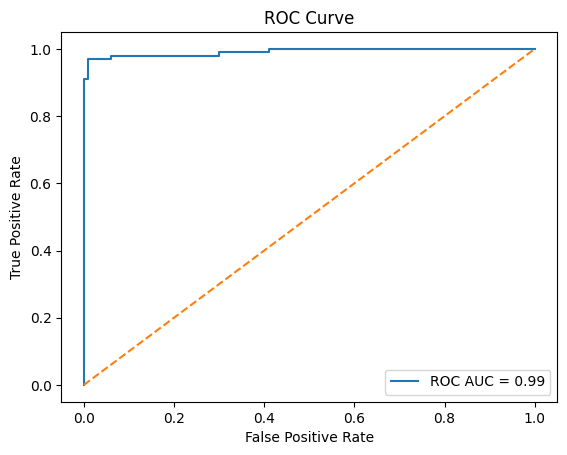

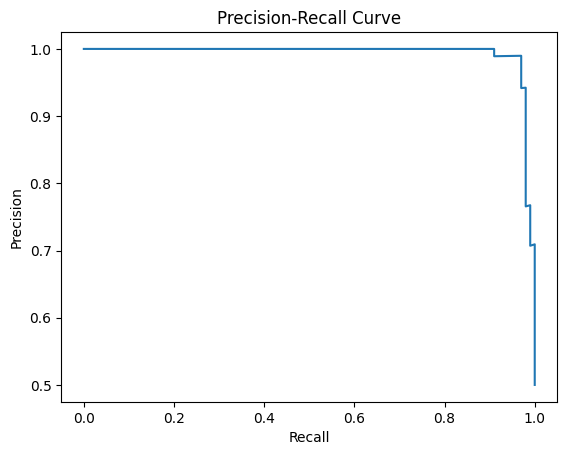

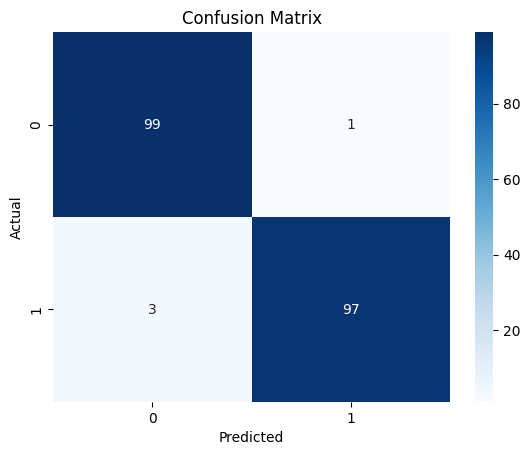

In [ ]:
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
# from custom_transformers import OutlierCapper
# from custom_transformers import TopKCategorical

# Load dataset
df = pd.read_csv("advertising.csv")
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hour'] = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek
df['Month'] = df['Timestamp'].dt.month
df = df.drop(columns=['Timestamp'])

X = df.drop(columns=['Clicked on Ad'])
y = df['Clicked on Ad']

# Train/test split (same as training)
_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Load trained model
with open("ctr_model.pkl", "rb") as f:
    model = pickle.load(f)

# Predictions
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

# Metrics
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

# --- Visualizations ---

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_score(y_test, y_proba):.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
print()

# Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_test, y_proba)
plt.figure()
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()
print()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
print()


# Script for future predictions
    app_prediction.py

In [ ]:
# app_predict.py
import pandas as pd
import pickle

# Load trained model
with open("ctr_model.pkl", "rb") as f:
    model = pickle.load(f)

# Example: new data (dictionary format)
new_user = pd.DataFrame([{
    "Daily Time Spent on Site": 65,
    "Age": 25,
    "Area Income": 55000,
    "Daily Internet Usage": 200,
    "Ad Topic Line": "Robust cloud orchestration",
    "City": "New York",
    "Male": 1,
    "Country": "United States",
    "Hour": 14,
    "DayOfWeek": 2,
    "Month": 9
}])

# Prediction
pred = model.predict(new_user)[0]
proba = model.predict_proba(new_user)[0][1]

print(f"Predicted Click: {pred}, Probability: {proba:.2f}")


Predicted Click: 0, Probability: 0.18
